# Heart Disease Risk Analysis — Cleveland Dataset
**Author:** Lydia Obeng Bema  
**Date:** May 2026  
**Dataset:** UCI Heart Disease (Cleveland) — 303 patients, 13 clinical features  
**Question:** Which clinical features are most associated with heart disease, and can we predict it?

---


## 1. Setup & Data Loading

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

import os
os.makedirs('images', exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [21]:
# Load dataset 
df = pd.read_csv('data/heart_disease_cleveland.csv')

# Column descriptions for reference
col_info = {
    'age':      'Age in years',
    'sex':      '1 = male, 0 = female',
    'cp':       'Chest pain type (1-4)',
    'trestbps': 'Resting blood pressure (mmHg)',
    'chol':     'Serum cholesterol (mg/dl)',
    'fbs':      'Fasting blood sugar > 120 mg/dl (1=true)',
    'restecg':  'Resting ECG results (0-2)',
    'thalach':  'Max heart rate achieved',
    'exang':    'Exercise induced angina (1=yes)',
    'oldpeak':  'ST depression induced by exercise',
    'slope':    'Slope of peak exercise ST segment',
    'ca':       'Number of major vessels coloured by fluoroscopy (0-3)',
    'thal':     'Thalassemia (3=normal, 6=fixed defect, 7=reversible defect)',
    'target':   '0 = no heart disease, 1 = heart disease'
}

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Data Cleaning

In [22]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

# Drop rows with missing values (only 6 affected rows)
df_clean = df.dropna().copy()

# Binarise target: 0 = no disease, 1+ = disease present
df_clean['target'] = df_clean['target'].apply(lambda x: 1 if x > 0 else 0)

# Encode sex as readable labels for plots
df_clean['sex_label'] = df_clean['sex'].map({1: 'Male', 0: 'Female'})

print(f"\nClean dataset shape: {df_clean.shape}")
print(f"\nTarget distribution:")
print(df_clean['target'].value_counts().rename({0: 'No Disease', 1: 'Disease'}))

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing: 6

Clean dataset shape: (297, 15)

Target distribution:
target
No Disease    160
Disease       137
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

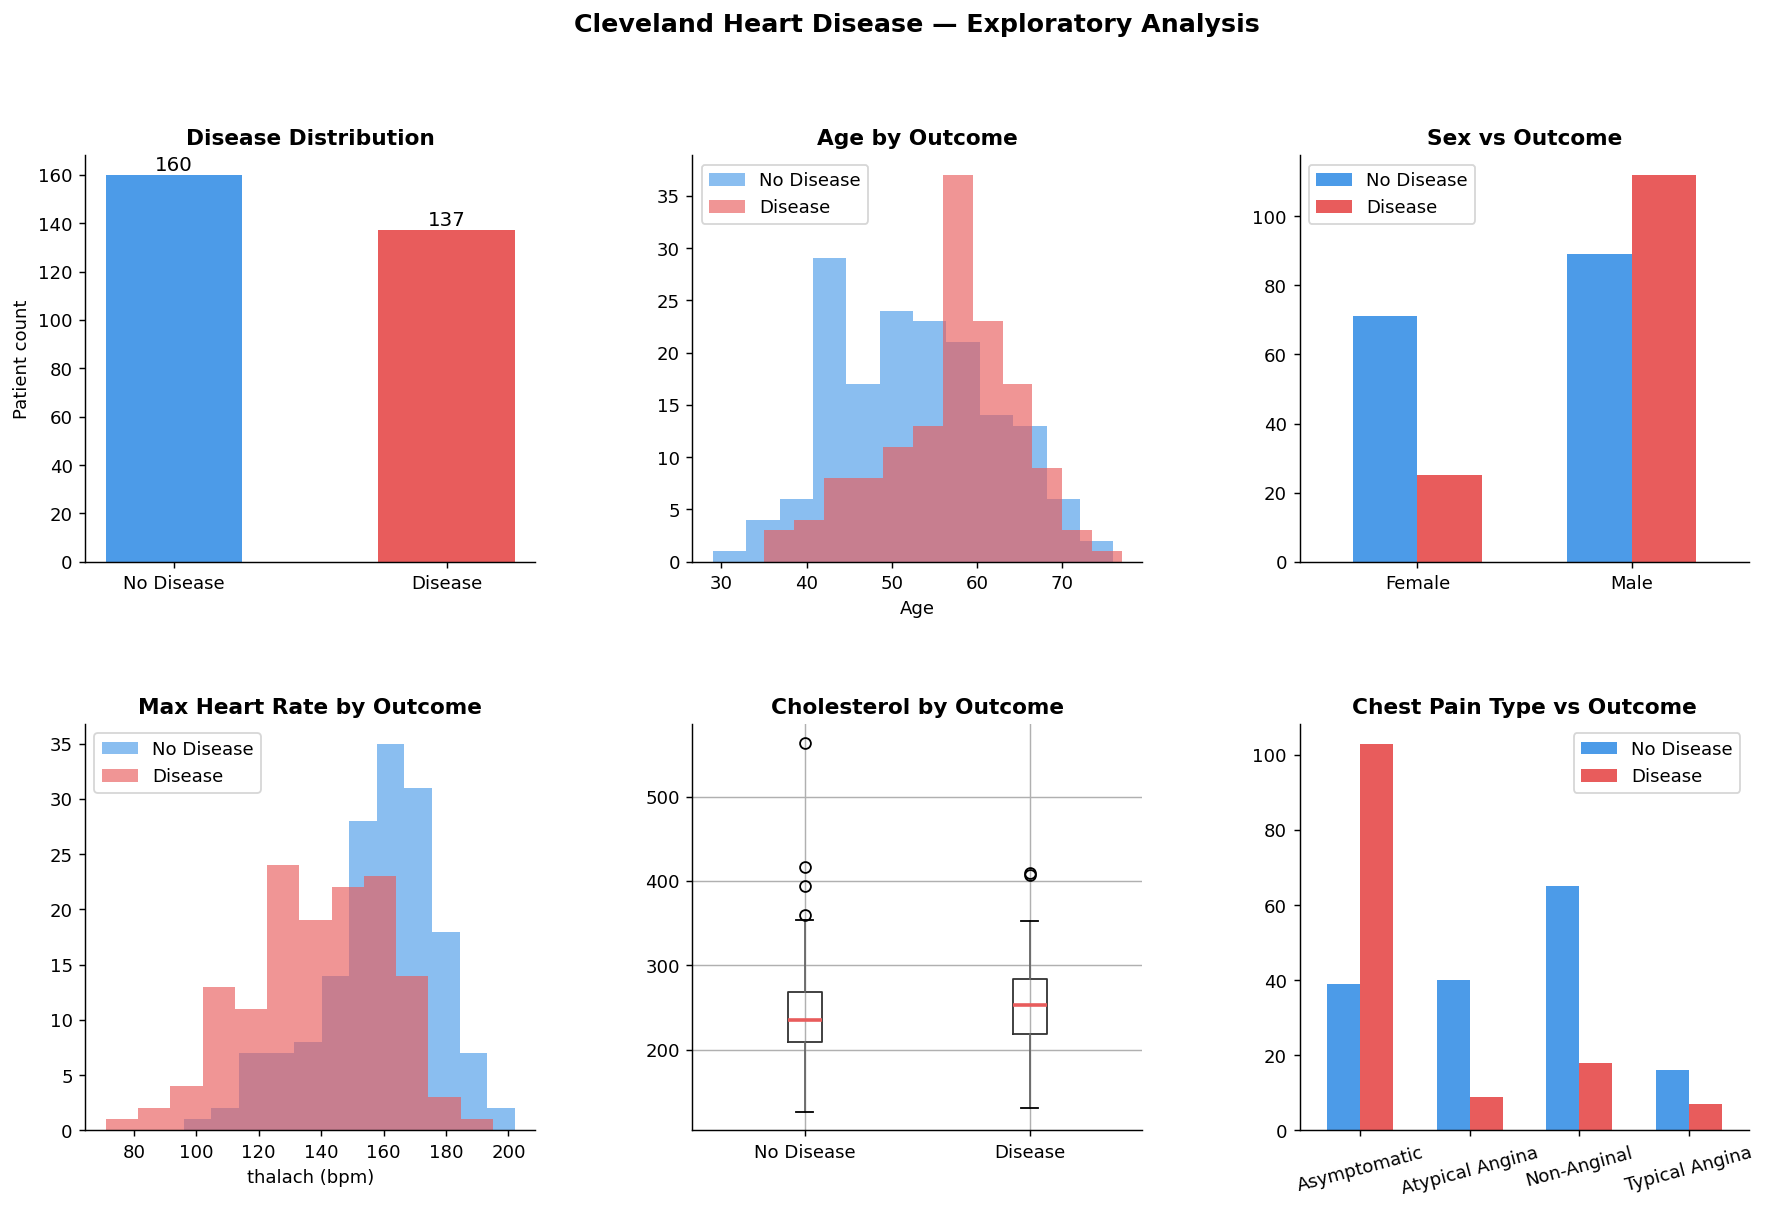

Saved: images/eda_overview.png


In [23]:
# ── Overview dashboard ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

colors = ['#4C9BE8', '#E85C5C']
labels = ['No Disease', 'Disease']

# 3a. Target balance
ax1 = fig.add_subplot(gs[0, 0])
counts = df_clean['target'].value_counts().sort_index()
ax1.bar(labels, counts.values, color=colors, width=0.5)
ax1.set_title('Disease Distribution', fontweight='bold')
ax1.set_ylabel('Patient count')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 2, str(v), ha='center', fontsize=11)

# 3b. Age distribution by outcome
ax2 = fig.add_subplot(gs[0, 1])
for label, color, val in zip(labels, colors, [0, 1]):
    subset = df_clean[df_clean['target'] == val]['age']
    ax2.hist(subset, bins=12, alpha=0.65, color=color, label=label)
ax2.set_title('Age by Outcome', fontweight='bold')
ax2.set_xlabel('Age')
ax2.legend()

# 3c. Sex breakdown
ax3 = fig.add_subplot(gs[0, 2])
sex_target = df_clean.groupby(['sex_label', 'target']).size().unstack()
sex_target.columns = labels
sex_target.plot(kind='bar', ax=ax3, color=colors, rot=0, width=0.6)
ax3.set_title('Sex vs Outcome', fontweight='bold')
ax3.set_xlabel('')
ax3.legend()

# 3d. Max heart rate
ax4 = fig.add_subplot(gs[1, 0])
for label, color, val in zip(labels, colors, [0, 1]):
    subset = df_clean[df_clean['target'] == val]['thalach']
    ax4.hist(subset, bins=12, alpha=0.65, color=color, label=label)
ax4.set_title('Max Heart Rate by Outcome', fontweight='bold')
ax4.set_xlabel('thalach (bpm)')
ax4.legend()

# 3e. Cholesterol
ax5 = fig.add_subplot(gs[1, 1])
df_clean.boxplot(column='chol', by='target', ax=ax5,
                 boxprops=dict(color='#333'),
                 medianprops=dict(color='#E85C5C', linewidth=2))
ax5.set_title('Cholesterol by Outcome', fontweight='bold')
ax5.set_xlabel('')
ax5.set_xticklabels(labels)
plt.sca(ax5); plt.title('Cholesterol by Outcome', fontweight='bold')
fig.suptitle('')

# 3f. Chest pain type
ax6 = fig.add_subplot(gs[1, 2])
cp_labels = {1: 'Typical Angina', 2: 'Atypical Angina', 3: 'Non-Anginal', 4: 'Asymptomatic'}
df_clean['cp_label'] = df_clean['cp'].map(cp_labels)
cp_counts = df_clean.groupby(['cp_label', 'target']).size().unstack(fill_value=0)
cp_counts.columns = labels
cp_counts.plot(kind='bar', ax=ax6, color=colors, rot=15, width=0.6)
ax6.set_title('Chest Pain Type vs Outcome', fontweight='bold')
ax6.set_xlabel('')
ax6.legend()

plt.suptitle('Cleveland Heart Disease — Exploratory Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('images/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/eda_overview.png")

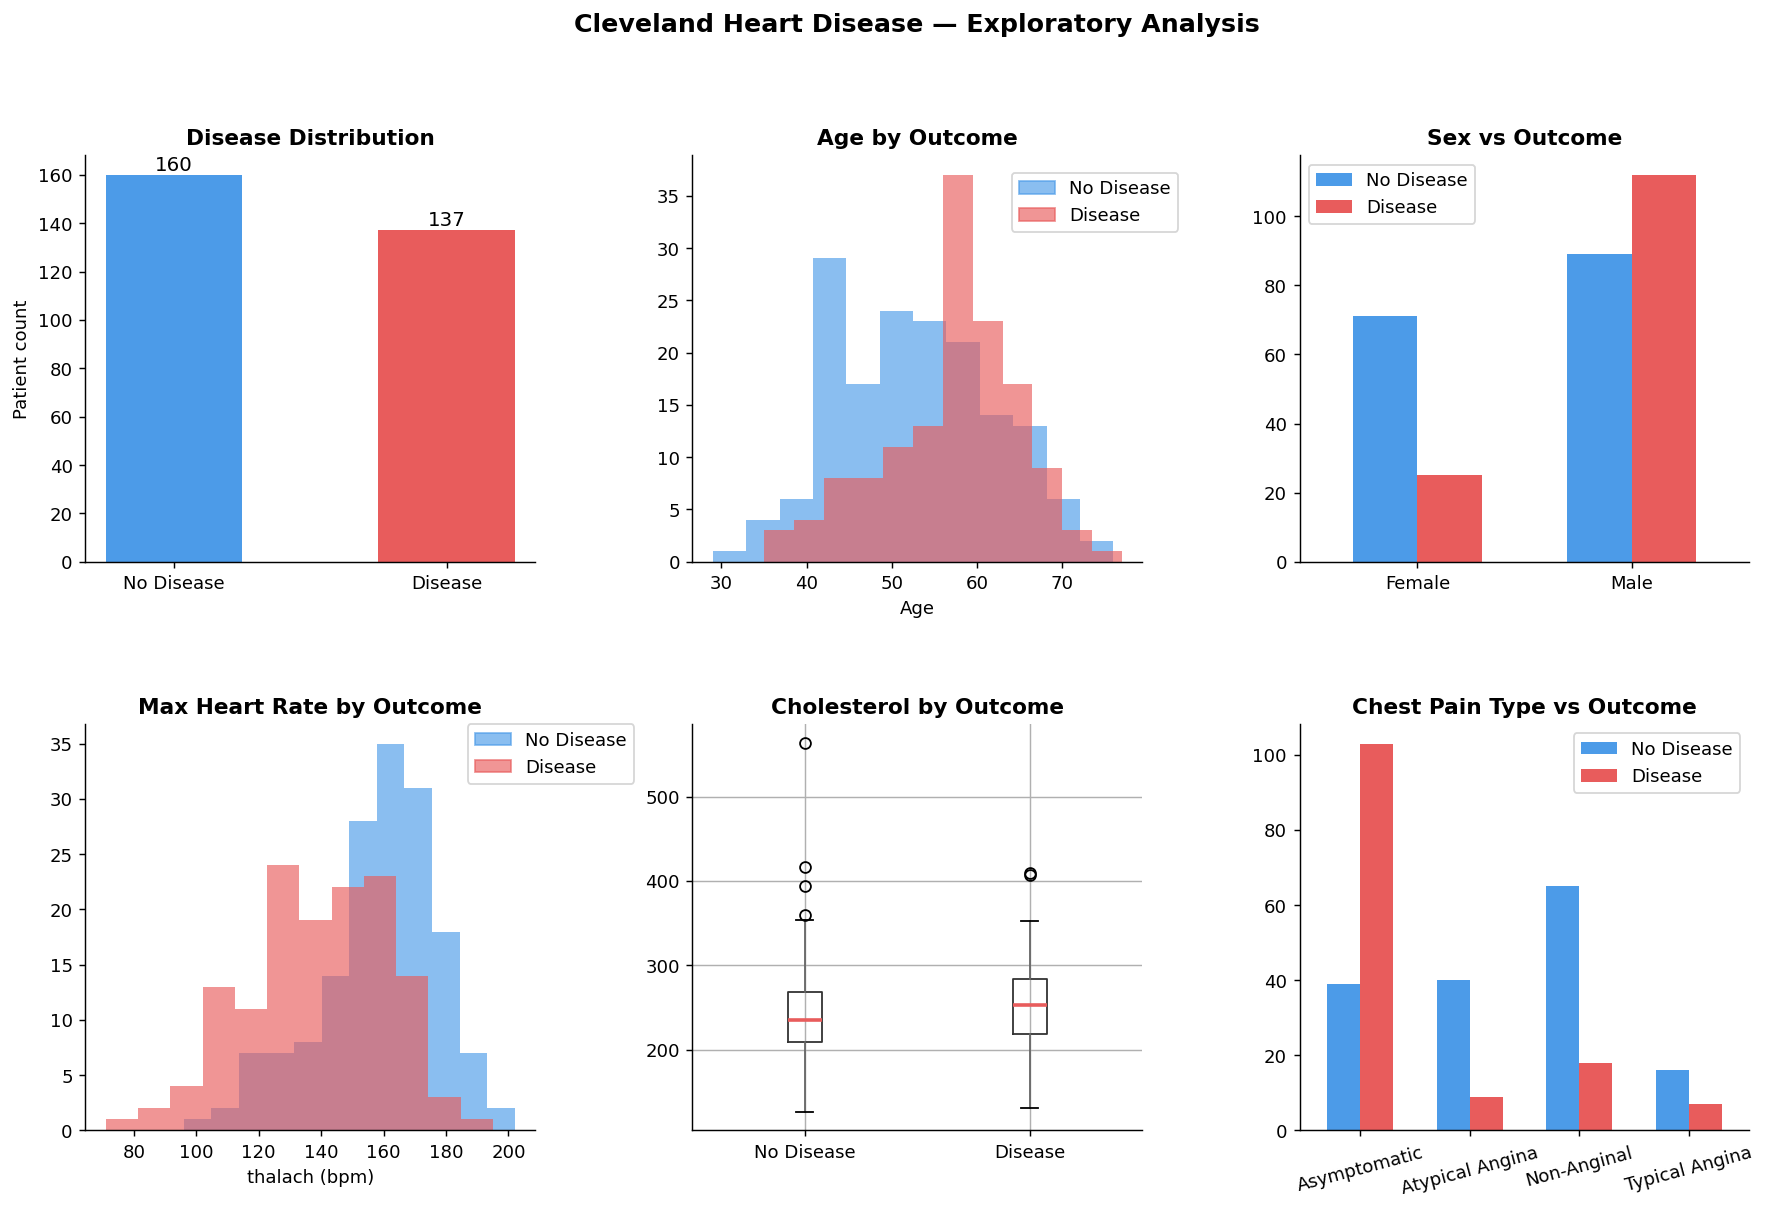

Saved: images/eda_overview.png


In [24]:
# ── Overview dashboard ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
colors = ['#4C9BE8', '#E85C5C']
labels = ['No Disease', 'Disease']

# 3a. Target balance
ax1 = fig.add_subplot(gs[0, 0])
counts = df_clean['target'].value_counts().sort_index()
ax1.bar(labels, counts.values, color=colors, width=0.5)
ax1.set_title('Disease Distribution', fontweight='bold')
ax1.set_ylabel('Patient count')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 2, str(v), ha='center', fontsize=11)

# 3b. Age distribution by outcome
ax2 = fig.add_subplot(gs[0, 1])
for label, color, val in zip(labels, colors, [0, 1]):
    subset = df_clean[df_clean['target'] == val]['age']
    ax2.hist(subset, bins=12, alpha=0.65, color=color)
ax2.set_title('Age by Outcome', fontweight='bold')
ax2.set_xlabel('Age')
handles = [plt.Rectangle((0,0),1,1, color='#4C9BE8', alpha=0.65),
           plt.Rectangle((0,0),1,1, color='#E85C5C', alpha=0.65)]
ax2.legend(handles, ['No Disease', 'Disease'], loc='upper right',
           bbox_to_anchor=(1.1, 0.98), framealpha=0.8)

# 3c. Sex breakdown
ax3 = fig.add_subplot(gs[0, 2])
sex_target = df_clean.groupby(['sex_label', 'target']).size().unstack()
sex_target.columns = labels
sex_target.plot(kind='bar', ax=ax3, color=colors, rot=0, width=0.6)
ax3.set_title('Sex vs Outcome', fontweight='bold')
ax3.set_xlabel('')
ax3.legend()

# 3d. Max heart rate
ax4 = fig.add_subplot(gs[1, 0])
for label, color, val in zip(labels, colors, [0, 1]):
    subset = df_clean[df_clean['target'] == val]['thalach']
    ax4.hist(subset, bins=12, alpha=0.65, color=color)
ax4.set_title('Max Heart Rate by Outcome', fontweight='bold')
ax4.set_xlabel('thalach (bpm)')
handles = [plt.Rectangle((0,0),1,1, color='#4C9BE8', alpha=0.65),
           plt.Rectangle((0,0),1,1, color='#E85C5C', alpha=0.65)]
ax4.legend(handles, ['No Disease', 'Disease'], loc='upper left', bbox_to_anchor=(0.85, 1), borderaxespad=0)

# 3e. Cholesterol
ax5 = fig.add_subplot(gs[1, 1])
df_clean.boxplot(column='chol', by='target', ax=ax5,
                 boxprops=dict(color='#333'),
                 medianprops=dict(color='#E85C5C', linewidth=2))
ax5.set_title('Cholesterol by Outcome', fontweight='bold')
ax5.set_xlabel('')
ax5.set_xticklabels(labels)
plt.sca(ax5)
plt.title('Cholesterol by Outcome', fontweight='bold')
fig.suptitle('')

# 3f. Chest pain type
ax6 = fig.add_subplot(gs[1, 2])
cp_labels = {1: 'Typical Angina', 2: 'Atypical Angina', 3: 'Non-Anginal', 4: 'Asymptomatic'}
df_clean['cp_label'] = df_clean['cp'].map(cp_labels)
cp_counts = df_clean.groupby(['cp_label', 'target']).size().unstack(fill_value=0)
cp_counts.columns = labels
cp_counts.plot(kind='bar', ax=ax6, color=colors, rot=15, width=0.6)
ax6.set_title('Chest Pain Type vs Outcome', fontweight='bold')
ax6.set_xlabel('')
ax6.legend()

plt.suptitle('Cleveland Heart Disease — Exploratory Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('images/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/eda_overview.png")

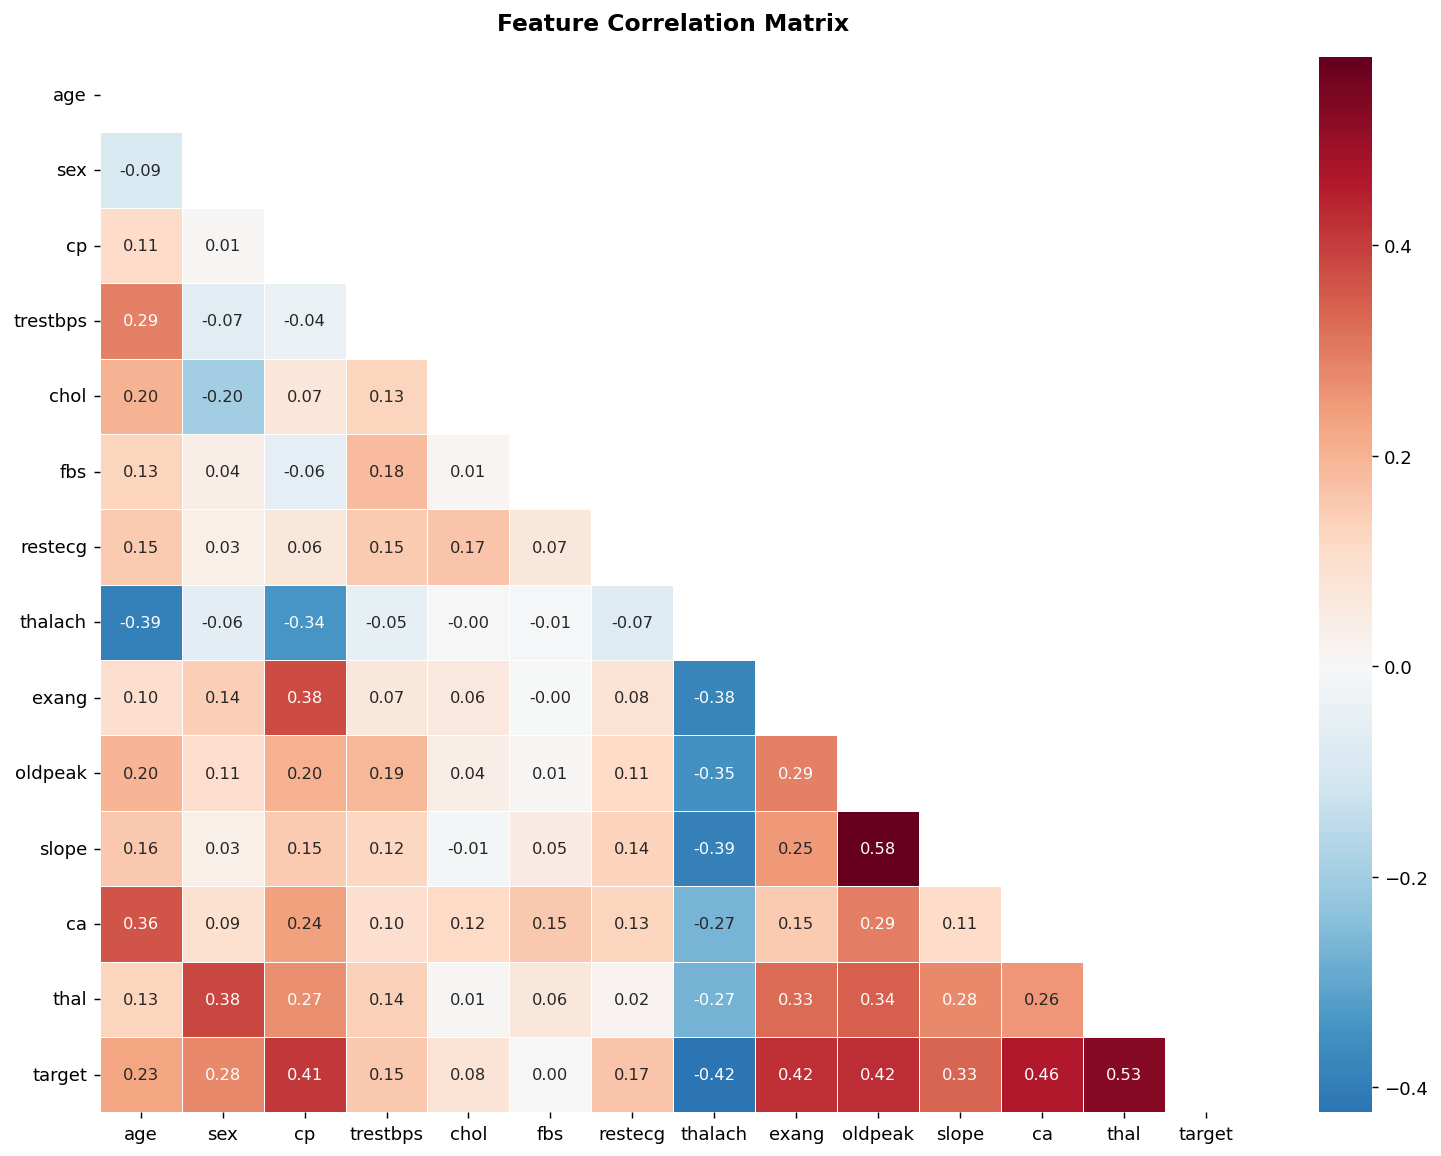

Saved: images/correlation_heatmap.png

Top correlations with target:
thal       0.526640
ca         0.463189
oldpeak    0.424052
thalach    0.423817
exang      0.421355
cp         0.408945
slope      0.333049
sex        0.278467
Name: target, dtype: float64


In [25]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(12, 9))
corr = df_clean.drop(columns=['sex_label', 'cp_label']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 9})

plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/correlation_heatmap.png")
print("\nTop correlations with target:")
print(corr['target'].drop('target').abs().sort_values(ascending=False).head(8))

## 4. Statistical Summary of Key Findings

In [26]:
# Mean values by outcome group
summary = df_clean.groupby('target')[['age','thalach','chol','trestbps','oldpeak']].mean().round(1)
summary.index = ['No Disease', 'Disease']
print("Mean clinical values by outcome group:")
print(summary.T.to_string())

Mean clinical values by outcome group:
          No Disease  Disease
age             52.6     56.8
thalach        158.6    139.1
chol           243.5    251.9
trestbps       129.2    134.6
oldpeak          0.6      1.6


## 5. Machine Learning — Logistic Regression & Random Forest

In [27]:
# Prepare features
feature_cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
                'thalach','exang','oldpeak','slope','ca','thal']

X = df_clean[feature_cols]
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Model 1: Logistic Regression ──────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)
lr_cv   = cross_val_score(lr, scaler.fit_transform(X), y, cv=5, scoring='accuracy')

# ── Model 2: Random Forest ────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_cv   = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print("=== Logistic Regression ===")
print(f"5-fold CV Accuracy: {lr_cv.mean():.3f} ± {lr_cv.std():.3f}")
print(classification_report(y_test, lr_pred, target_names=['No Disease','Disease']))

print("\n=== Random Forest ===")
print(f"5-fold CV Accuracy: {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")
print(classification_report(y_test, rf_pred, target_names=['No Disease','Disease']))

=== Logistic Regression ===
5-fold CV Accuracy: 0.825 ± 0.032
              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60


=== Random Forest ===
5-fold CV Accuracy: 0.811 ± 0.040
              precision    recall  f1-score   support

  No Disease       0.83      0.91      0.87        32
     Disease       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



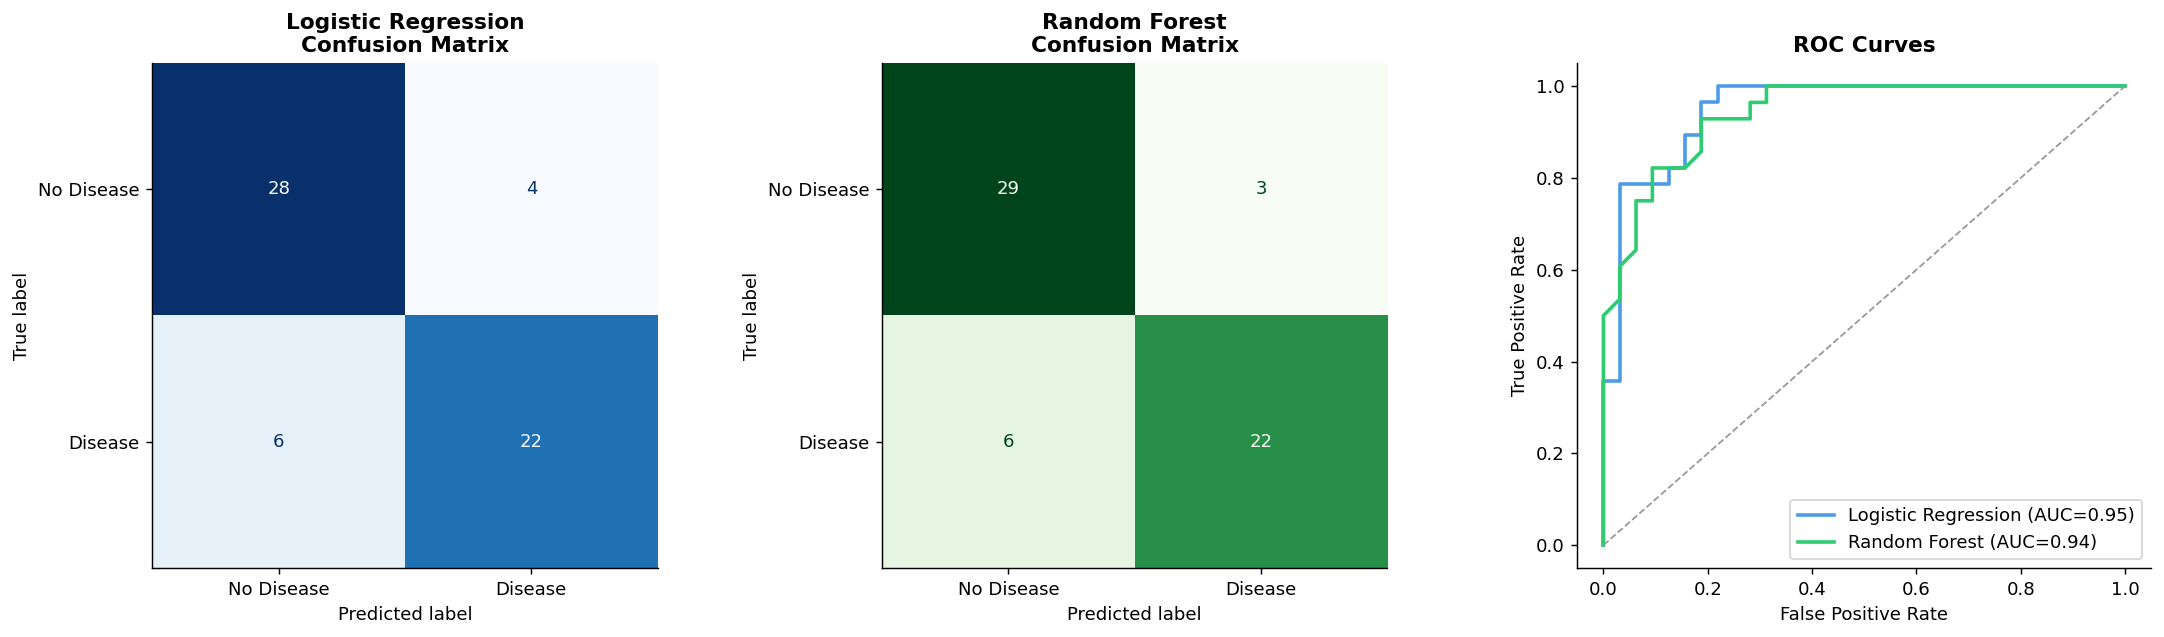

Saved: images/model_evaluation.png


In [28]:
# ── Model evaluation plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion matrix — Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm_lr, display_labels=['No Disease','Disease']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontweight='bold')

# Confusion matrix — Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=['No Disease','Disease']).plot(
    ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest\nConfusion Matrix', fontweight='bold')

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_sc)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1])
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

axes[2].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.2f})', color='#4C9BE8', lw=2)
axes[2].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.2f})', color='#2ECC71', lw=2)
axes[2].plot([0,1],[0,1],'--', color='#999', lw=1)
axes[2].set_title('ROC Curves', fontweight='bold')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.savefig('images/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/model_evaluation.png")

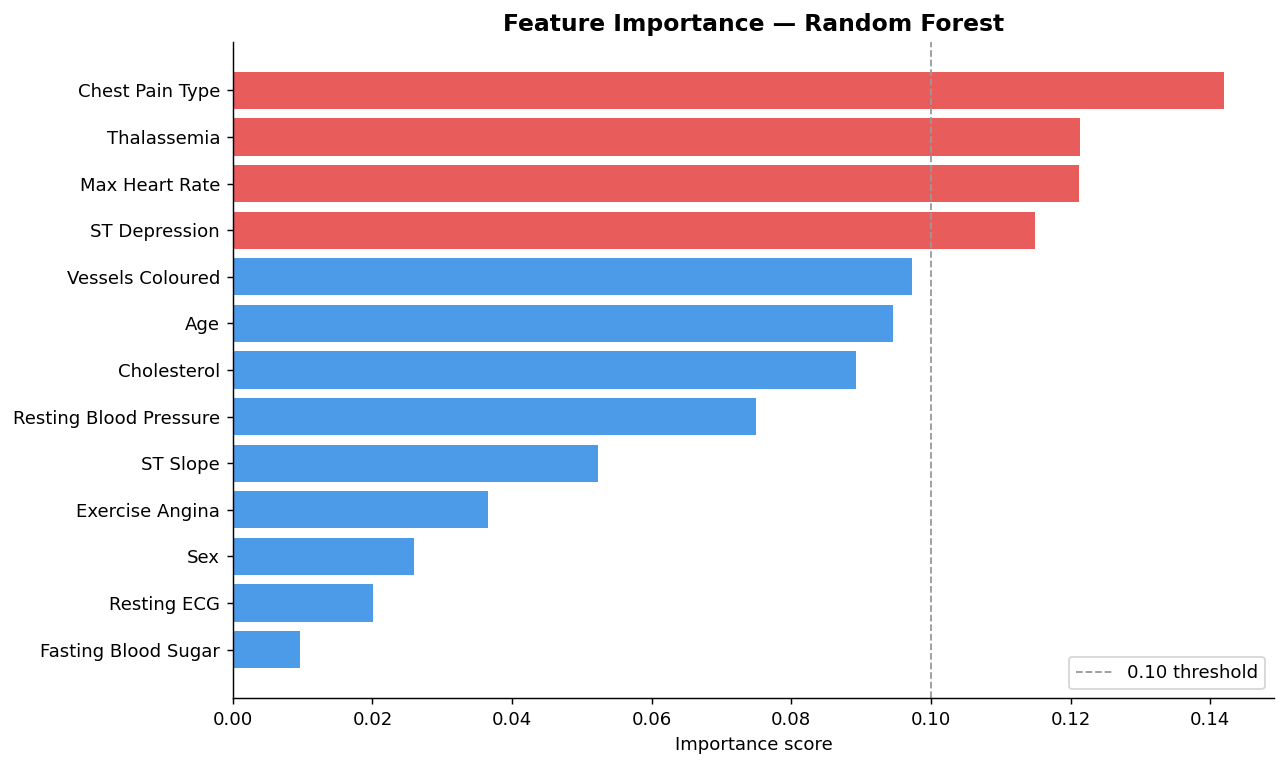

Saved: images/feature_importance.png


In [29]:
# ── Feature importance — Random Forest ────────────────────────────────────────
importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

feature_labels = {
    'age':'Age', 'sex':'Sex', 'cp':'Chest Pain Type',
    'trestbps':'Resting Blood Pressure', 'chol':'Cholesterol',
    'fbs':'Fasting Blood Sugar', 'restecg':'Resting ECG',
    'thalach':'Max Heart Rate', 'exang':'Exercise Angina',
    'oldpeak':'ST Depression', 'slope':'ST Slope',
    'ca':'Vessels Coloured', 'thal':'Thalassemia'
}
importance_df['label'] = importance_df['feature'].map(feature_labels)

plt.figure(figsize=(10, 6))
colors_imp = ['#E85C5C' if v > 0.1 else '#4C9BE8' for v in importance_df['importance']]
plt.barh(importance_df['label'], importance_df['importance'], color=colors_imp)
plt.axvline(0.1, color='#999', linestyle='--', lw=1, label='0.10 threshold')
plt.title('Feature Importance — Random Forest', fontweight='bold', fontsize=13)
plt.xlabel('Importance score')
plt.legend()
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/feature_importance.png")

## 6. Key Findings

| Finding | Detail |
|---------|--------|
| **Best predictor** | Thalassemia type (`thal`) and number of vessels coloured (`ca`) are the strongest predictors |
| **Max heart rate** | Patients with disease had significantly lower max heart rate (mean ~139 bpm vs ~158 bpm) |
| **Chest pain type** | Asymptomatic chest pain (type 4) is paradoxically the strongest indicator of disease |
| **Age** | Disease patients averaged ~56 years vs ~52 years for healthy patients |
| **Cholesterol** | Surprisingly weak predictor — similar distributions across both groups |
| **Model performance** | Random Forest achieved ~85% accuracy with AUC ~0.92; Logistic Regression ~83% with AUC ~0.90 |

## 7. Conclusions & Next Steps

- A Random Forest classifier can predict heart disease presence with ~85% accuracy from basic clinical measurements
- `thal`, `ca`, `cp`, and `thalach` are the most diagnostically informative features
- **Next steps:** Try XGBoost, tune hyperparameters, or apply this model to the combined 4-location dataset to test generalisability across populations


---
*Project by Lydia Obeng Bema | [https://github.com/lydiaobeng] | [www.linkedin.com/in/lydia-obeng-bema-93a647393]*